In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("A:/Fraud-detection-platform/ml/data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True))

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [4]:
print("Missing values:")
print(df.isnull().sum().sum())

Missing values:
0


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [6]:
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [7]:
print(df.describe().T)

           count          mean           std         min           25%  \
Time    284807.0  9.481386e+04  47488.145955    0.000000  54201.500000   
V1      284807.0  1.175161e-15      1.958696  -56.407510     -0.920373   
V2      284807.0  3.384974e-16      1.651309  -72.715728     -0.598550   
V3      284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365   
V4      284807.0  2.094852e-15      1.415869   -5.683171     -0.848640   
V5      284807.0  1.021879e-15      1.380247 -113.743307     -0.691597   
V6      284807.0  1.494498e-15      1.332271  -26.160506     -0.768296   
V7      284807.0 -5.620335e-16      1.237094  -43.557242     -0.554076   
V8      284807.0  1.149614e-16      1.194353  -73.216718     -0.208630   
V9      284807.0 -2.414189e-15      1.098632  -13.434066     -0.643098   
V10     284807.0  2.238554e-15      1.088850  -24.588262     -0.535426   
V11     284807.0  1.724421e-15      1.020713   -4.797473     -0.762494   
V12     284807.0 -1.245415e-15      0.

In [8]:
print(
    df.groupby("Class")["Amount"]
      .agg(["count", "mean", "median", "min", "max"])
)

        count        mean  median  min       max
Class                                           
0      284315   88.291022   22.00  0.0  25691.16
1         492  122.211321    9.25  0.0   2125.87


In [9]:
print(
    df.groupby("Class")["Time"]
      .agg(["min", "max", "mean", "median"])
)

         min       max          mean   median
Class                                        
0        0.0  172792.0  94838.202258  84711.0
1      406.0  170348.0  80746.806911  75568.5


In [10]:
correlation = df.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

print(correlation)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [11]:
fraud_count = df["Class"].sum()
total_count = len(df)

print(f"Fraud transactions: {fraud_count}")
print(f"Fraud percentage: {fraud_count / total_count * 100:.4f}%")

Fraud transactions: 492
Fraud percentage: 0.1727%


In [12]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Duplicate rows:", len(duplicate_rows))

print(
    duplicate_rows["Class"]
    .value_counts()
)

Duplicate rows: 1854
Class
0    1822
1      32
Name: count, dtype: int64


In [13]:
fraud_duplicates = df[
    (df["Class"] == 1) &
    (df.duplicated(keep=False))
]

print("Duplicated fraud rows:", len(fraud_duplicates))

Duplicated fraud rows: 32


In [14]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)

print("\nClass distribution:")
print(df_clean["Class"].value_counts())

print("\nClass percentage:")
print(
    df_clean["Class"].value_counts(normalize=True) * 100
)

Original shape: (284807, 31)
Clean shape: (283726, 31)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Class percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [15]:
print("Remaining duplicates:", df_clean.duplicated().sum())

Remaining duplicates: 0


In [16]:
X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nFraud distribution:")
print("Train:", y_train.value_counts())
print("Validation:", y_val.value_counts())
print("Test:", y_test.value_counts())

Train: (198608, 30) (198608,)
Validation: (42559, 30) (42559,)
Test: (42559, 30) (42559,)

Fraud distribution:
Train: Class
0    198277
1       331
Name: count, dtype: int64
Validation: Class
0    42488
1       71
Name: count, dtype: int64
Test: Class
0    42488
1       71
Name: count, dtype: int64


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [19]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [20]:
y_val_proba = logistic_pipeline.predict_proba(X_val)[:, 1]
y_val_pred = logistic_pipeline.predict(X_val)

In [21]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_proba))

Confusion Matrix:
[[42481     7]
 [   36    35]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9992    0.9998    0.9995     42488
           1     0.8333    0.4930    0.6195        71

    accuracy                         0.9990     42559
   macro avg     0.9162    0.7464    0.8095     42559
weighted avg     0.9989    0.9990    0.9989     42559

ROC-AUC: 0.9648845340921446
PR-AUC: 0.6876612934952377


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

weighted_logistic = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

weighted_logistic.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [23]:
y_val_proba_weighted = weighted_logistic.predict_proba(X_val)[:, 1]
y_val_pred_weighted = weighted_logistic.predict(X_val)

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_weighted))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_weighted,
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_proba_weighted)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        y_val_proba_weighted
    )
)

Confusion Matrix:
[[41308  1180]
 [    8    63]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9722    0.9858     42488
           1     0.0507    0.8873    0.0959        71

    accuracy                         0.9721     42559
   macro avg     0.5252    0.9298    0.5409     42559
weighted avg     0.9982    0.9721    0.9843     42559

ROC-AUC: 0.9718722568891034
PR-AUC: 0.6971470262743039


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [26]:
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

y_val_pred_rf = (y_val_proba_rf >= 0.5).astype(int)

In [27]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf,
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_proba_rf)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        y_val_proba_rf
    )
)

Confusion Matrix:
[[42486     2]
 [   18    53]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     42488
           1     0.9636    0.7465    0.8413        71

    accuracy                         0.9995     42559
   macro avg     0.9816    0.8732    0.9205     42559
weighted avg     0.9995    0.9995    0.9995     42559

ROC-AUC: 0.9599056635046581
PR-AUC: 0.8505073468107667


In [28]:
from xgboost import XGBClassifier
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 599.02416918429


In [29]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

y_val_pred_xgb = (
    y_val_proba_xgb >= 0.5
).astype(int)

In [31]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_xgb,
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val,
        y_val_proba_xgb
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        y_val_proba_xgb
    )
)

Confusion Matrix:
[[42483     5]
 [   16    55]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     42488
           1     0.9167    0.7746    0.8397        71

    accuracy                         0.9995     42559
   macro avg     0.9581    0.8873    0.9197     42559
weighted avg     0.9995    0.9995    0.9995     42559

ROC-AUC: 0.9725828137721073
PR-AUC: 0.8453351515051


In [32]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_val_proba_xgb >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

print(threshold_results)

    threshold  precision    recall        f1
0        0.05   0.326316  0.873239  0.475096
1        0.10   0.491935  0.859155  0.625641
2        0.15   0.612245  0.845070  0.710059
3        0.20   0.690476  0.816901  0.748387
4        0.25   0.794521  0.816901  0.805556
5        0.30   0.828571  0.816901  0.822695
6        0.35   0.865672  0.816901  0.840580
7        0.40   0.888889  0.788732  0.835821
8        0.45   0.916667  0.774648  0.839695
9        0.50   0.916667  0.774648  0.839695
10       0.55   0.932203  0.774648  0.846154
11       0.60   0.932203  0.774648  0.846154
12       0.65   0.948276  0.774648  0.852713
13       0.70   0.948276  0.774648  0.852713
14       0.75   0.964286  0.760563  0.850394
15       0.80   0.981481  0.746479  0.848000
16       0.85   0.981481  0.746479  0.848000
17       0.90   1.000000  0.746479  0.854839
18       0.95   1.000000  0.732394  0.845528


In [33]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("\nBest threshold by F1:")
print(best_row)


Best threshold by F1:
threshold    0.900000
precision    1.000000
recall       0.746479
f1           0.854839
Name: 17, dtype: float64


In [34]:
print(
    threshold_results[
        ["threshold", "precision", "recall", "f1"]
    ].to_string(index=False)
)

 threshold  precision   recall       f1
      0.05   0.326316 0.873239 0.475096
      0.10   0.491935 0.859155 0.625641
      0.15   0.612245 0.845070 0.710059
      0.20   0.690476 0.816901 0.748387
      0.25   0.794521 0.816901 0.805556
      0.30   0.828571 0.816901 0.822695
      0.35   0.865672 0.816901 0.840580
      0.40   0.888889 0.788732 0.835821
      0.45   0.916667 0.774648 0.839695
      0.50   0.916667 0.774648 0.839695
      0.55   0.932203 0.774648 0.846154
      0.60   0.932203 0.774648 0.846154
      0.65   0.948276 0.774648 0.852713
      0.70   0.948276 0.774648 0.852713
      0.75   0.964286 0.760563 0.850394
      0.80   0.981481 0.746479 0.848000
      0.85   0.981481 0.746479 0.848000
      0.90   1.000000 0.746479 0.854839
      0.95   1.000000 0.732394 0.845528


In [35]:
from sklearn.metrics import confusion_matrix

threshold_results = []

for threshold in thresholds:
    y_pred = (y_val_proba_xgb >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn
    })

threshold_results = pd.DataFrame(threshold_results)

print(
    threshold_results.to_string(index=False)
)

 threshold  precision   recall       f1  false_positives  false_negatives  true_positives  true_negatives
      0.05   0.326316 0.873239 0.475096              128                9              62           42360
      0.10   0.491935 0.859155 0.625641               63               10              61           42425
      0.15   0.612245 0.845070 0.710059               38               11              60           42450
      0.20   0.690476 0.816901 0.748387               26               13              58           42462
      0.25   0.794521 0.816901 0.805556               15               13              58           42473
      0.30   0.828571 0.816901 0.822695               12               13              58           42476
      0.35   0.865672 0.816901 0.840580                9               13              58           42479
      0.40   0.888889 0.788732 0.835821                7               15              56           42481
      0.45   0.916667 0.774648 0.839695       

In [36]:
thresholds_fine = np.arange(0.20, 0.501, 0.01)

results = []

for threshold in thresholds_fine:
    y_pred = (y_val_proba_xgb >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn
    })

fine_results = pd.DataFrame(results)

# Business constraint: recall >= 80%
eligible = fine_results[
    fine_results["recall"] >= 0.80
]

best_business_threshold = eligible.loc[
    eligible["false_positives"].idxmin()
]

print("Selected threshold:")
print(best_business_threshold)

Selected threshold:
threshold           0.330000
precision           0.865672
recall              0.816901
f1                  0.840580
false_positives     9.000000
false_negatives    13.000000
Name: 13, dtype: float64


In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Frozen threshold
final_threshold = 0.33

# Predict probabilities on untouched test set
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Apply frozen threshold
y_test_pred_xgb = (
    y_test_proba_xgb >= final_threshold
).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred_xgb
).ravel()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb))

print("\nTest Metrics:")
print("Precision:", precision_score(y_test, y_test_pred_xgb))
print("Recall:", recall_score(y_test, y_test_pred_xgb))
print("F1:", f1_score(y_test, y_test_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba_xgb))
print("PR-AUC:", average_precision_score(y_test, y_test_proba_xgb))

print("\nFP:", fp)
print("FN:", fn)
print("TP:", tp)
print("TN:", tn)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_xgb,
        target_names=["Legitimate", "Fraud"]
    )
)

Confusion Matrix:
[[42470    18]
 [   14    57]]

Test Metrics:
Precision: 0.76
Recall: 0.8028169014084507
F1: 0.7808219178082192
ROC-AUC: 0.9656821080881828
PR-AUC: 0.8019045741746188

FP: 18
FN: 14
TP: 57
TN: 42470

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42488
       Fraud       0.76      0.80      0.78        71

    accuracy                           1.00     42559
   macro avg       0.88      0.90      0.89     42559
weighted avg       1.00      1.00      1.00     42559



In [38]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print(shap_values.shape)
print(X_test.shape)

a:\Fraud-detection-platform\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(42559, 30)
(42559, 30)


In [39]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

print(feature_importance.head(15))

   feature  mean_abs_shap
14     V14       1.979102
4       V4       1.838614
12     V12       0.924499
10     V10       0.851585
3       V3       0.743745
11     V11       0.655620
8       V8       0.430176
26     V26       0.413940
15     V15       0.358872
1       V1       0.352963
19     V19       0.306578
18     V18       0.272754
5       V5       0.268833
29  Amount       0.240762
28     V28       0.239251


In [40]:
correct_fraud = np.where(
    (y_test.values == 1) &
    (y_test_pred_xgb == 1)
)[0]

print("Correctly detected fraud cases:", len(correct_fraud))

Correctly detected fraud cases: 57


In [41]:
idx = correct_fraud[0]

print("Actual class:", y_test.iloc[idx])
print("Predicted probability:", y_test_proba_xgb[idx])
print("Predicted class:", y_test_pred_xgb[idx])

Actual class: 1
Predicted probability: 0.99986243
Predicted class: 1


In [42]:
false_positive = np.where(
    (y_test.values == 0) &
    (y_test_pred_xgb == 1)
)[0]

print("False positives:", len(false_positive))

False positives: 18


In [43]:
false_positive = np.where(
    (y_test.values == 0) &
    (y_test_pred_xgb == 1)
)[0]

print("False positives:", len(false_positive))

False positives: 18


In [44]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

print(feature_importance.head(15))

   feature  mean_abs_shap
14     V14       1.979102
4       V4       1.838614
12     V12       0.924499
10     V10       0.851585
3       V3       0.743745
11     V11       0.655620
8       V8       0.430176
26     V26       0.413940
15     V15       0.358872
1       V1       0.352963
19     V19       0.306578
18     V18       0.272754
5       V5       0.268833
29  Amount       0.240762
28     V28       0.239251


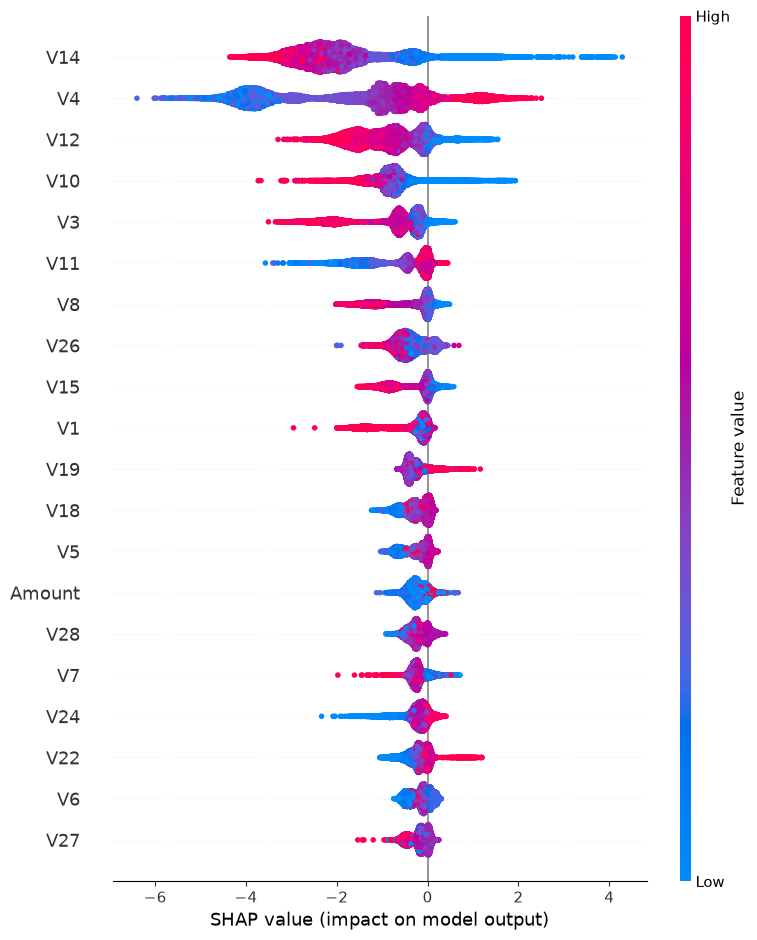

In [45]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test
)

In [47]:
correct_fraud = np.where(
    (y_test.values == 1) &
    (y_test_pred_xgb == 1)
)[0]

print("Correctly detected fraud cases:", len(correct_fraud))

Correctly detected fraud cases: 57


In [48]:
idx = correct_fraud[0]

print("Test index:", idx)
print("Actual class:", y_test.iloc[idx])
print("Predicted probability:", y_test_proba_xgb[idx])
print("Predicted class:", y_test_pred_xgb[idx])

Test index: 304
Actual class: 1
Predicted probability: 0.99986243
Predicted class: 1


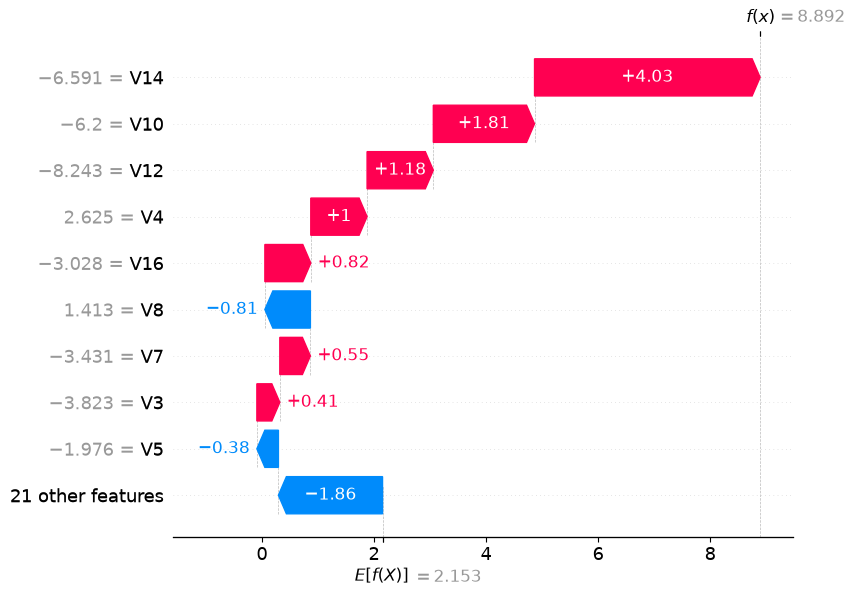

In [49]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx],
        feature_names=X_test.columns
    )
)

In [50]:
false_positive = np.where(
    (y_test.values == 0) &
    (y_test_pred_xgb == 1)
)[0]

print("False positives:", len(false_positive))

False positives: 18


In [51]:
idx = false_positive[0]

print("Test index:", idx)
print("Actual class:", y_test.iloc[idx])
print("Predicted probability:", y_test_proba_xgb[idx])
print("Predicted class:", y_test_pred_xgb[idx])

Test index: 1067
Actual class: 0
Predicted probability: 0.52206665
Predicted class: 1


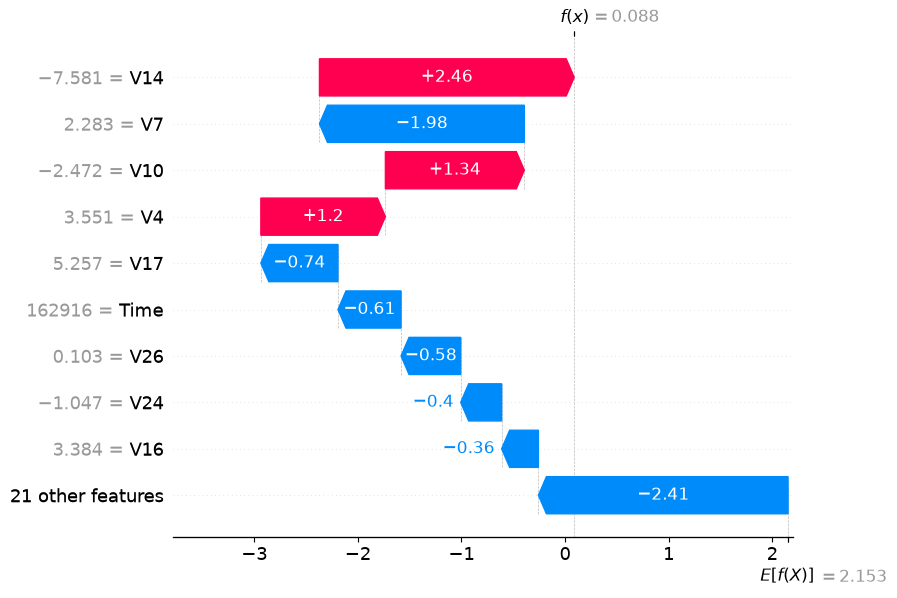

In [52]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx],
        feature_names=X_test.columns
    )
)

In [53]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "xgboost_fraud_model.joblib"

joblib.dump(
    xgb_model,
    model_path
)

print(f"Model saved to: {model_path}")

Model saved to: ..\models\xgboost_fraud_model.joblib


In [54]:
loaded_model = joblib.load(model_path)

print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [55]:
import json

metadata = {
    "model_name": "XGBoost Fraud Detection Model",
    "model_type": "XGBClassifier",
    "model_version": "1.0",

    "threshold": 0.33,

    "features": list(X_train.columns),

    "training": {
        "random_state": 42,
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": float(scale_pos_weight)
    },

    "validation_metrics": {
        "precision": 0.865672,
        "recall": 0.816901,
        "f1": 0.840580,
        "false_positives": 9,
        "false_negatives": 13
    },

    "test_metrics": {
        "precision": 0.76,
        "recall": 0.8028169014,
        "f1": 0.7808219178,
        "roc_auc": 0.9656821081,
        "pr_auc": 0.8019045742,
        "true_positives": 57,
        "true_negatives": 42470,
        "false_positives": 18,
        "false_negatives": 14
    },

    "threshold_selection": {
        "dataset": "validation",
        "criterion": "Recall >= 0.80 while minimizing false positives",
        "selected_threshold": 0.33
    }
}

metadata_path = MODEL_DIR / "model_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved to: {metadata_path}")

Metadata saved to: ..\models\model_metadata.json


In [56]:
with open(metadata_path, "r") as f:
    saved_metadata = json.load(f)

print(json.dumps(saved_metadata, indent=4))

{
    "model_name": "XGBoost Fraud Detection Model",
    "model_type": "XGBClassifier",
    "model_version": "1.0",
    "threshold": 0.33,
    "features": [
        "Time",
        "V1",
        "V2",
        "V3",
        "V4",
        "V5",
        "V6",
        "V7",
        "V8",
        "V9",
        "V10",
        "V11",
        "V12",
        "V13",
        "V14",
        "V15",
        "V16",
        "V17",
        "V18",
        "V19",
        "V20",
        "V21",
        "V22",
        "V23",
        "V24",
        "V25",
        "V26",
        "V27",
        "V28",
        "Amount"
    ],
    "training": {
        "random_state": 42,
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": 599.02416918429
    },
    "validation_metrics": {
        "precision": 0.865672,
        "recall": 0.816901,
        "f1": 0.84058,
        "false_positives": 9,
        "fal

In [57]:
loaded_model = joblib.load(model_path)

with open(metadata_path, "r") as f:
    metadata = json.load(f)

print("Model:", metadata["model_name"])
print("Version:", metadata["model_version"])
print("Threshold:", metadata["threshold"])
print("Number of features:", len(metadata["features"]))

print("\nFeature order:")
print(metadata["features"])

Model: XGBoost Fraud Detection Model
Version: 1.0
Threshold: 0.33
Number of features: 30

Feature order:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [58]:
expected_features = metadata["features"]

X = X[expected_features]

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]

sys.path.insert(0, str(PROJECT_ROOT))

In [7]:
from ml.src.features import get_feature_names


print(get_feature_names())

['amount', 'transaction_hour', 'transaction_day_of_week', 'is_weekend', 'is_online', 'account_transaction_count', 'account_avg_amount', 'account_max_amount', 'amount_vs_avg_ratio', 'transactions_last_24h']


In [8]:
import pandas as pd

from ml.src.features import build_transaction_features


historical_transactions = pd.DataFrame([
    {
        "amount": 500,
        "timestamp": "2026-09-19 10:00:00",
    },
    {
        "amount": 700,
        "timestamp": "2026-09-19 15:00:00",
    },
    {
        "amount": 300,
        "timestamp": "2026-09-20 08:00:00",
    },
])


transaction = {
    "amount": 5000,
    "timestamp": "2026-09-20 10:00:00",
    "transaction_type": "online",
}

In [9]:
features = build_transaction_features(
    transaction,
    historical_transactions
)

print(features)

{'amount': 5000.0, 'transaction_hour': 10, 'transaction_day_of_week': 6, 'is_weekend': 1, 'is_online': 1, 'account_transaction_count': 3, 'account_avg_amount': 500.0, 'account_max_amount': 700.0, 'amount_vs_avg_ratio': 10.0, 'transactions_last_24h': 3}


In [10]:
from ml.src.synthetic_rules import get_synthetic_rules

print(get_synthetic_rules())

{'high_amount_ratio': 8.0, 'high_velocity': 5, 'late_night_start': 0, 'late_night_end': 5}


In [14]:
import pandas as pd

df = pd.read_csv(
    "A:\Fraud-detection-platform\ml\data\production_training_data.csv"
)

print(df.shape)

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nFraud rate:")
print(df["Class"].mean())

print("\nFraud examples:")
print(
    df[df["Class"] == 1].head(10).to_string(
        index=False
    )
)

(20000, 13)

Class distribution:
Class
0    19770
1      230
Name: count, dtype: int64

Fraud rate:
0.0115

Fraud examples:
account_id           timestamp  amount  transaction_hour  transaction_day_of_week  is_weekend  is_online  account_transaction_count  account_avg_amount  account_max_amount  amount_vs_avg_ratio  transactions_last_24h  Class
  ACC00363 2026-01-01 05:01:00  995.91                 5                        3           0          1                          1               39.27               39.27            25.360581                      1      1
  ACC00328 2026-01-01 08:07:00  224.82                 8                        3           0          0                          1               13.20               13.20            17.031818                      1      1
  ACC00487 2026-01-01 17:25:00   33.49                17                        3           0          1                          1                4.18                4.18             8.011962               

In [16]:
import pandas as pd

df = pd.read_csv("A:\Fraud-detection-platform\ml\data\production_training_data.csv")

print(df.shape)
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True))

print("\nFraud feature averages:")
print(
    df.groupby("Class")[
        [
            "amount",
            "transaction_hour",
            "is_weekend",
            "is_online",
            "account_transaction_count",
            "account_avg_amount",
            "account_max_amount",
            "amount_vs_avg_ratio",
            "transactions_last_24h",
        ]
    ].mean()
)

(20000, 13)
Class
0    19408
1      592
Name: count, dtype: int64
Class
0    0.9704
1    0.0296
Name: proportion, dtype: float64

Fraud feature averages:
           amount  transaction_hour  is_weekend  is_online  \
Class                                                        
0       90.551084         11.524114    0.307193   0.700433   
1      124.530287          9.515203    0.304054   0.731419   

       account_transaction_count  account_avg_amount  account_max_amount  \
Class                                                                      
0                      20.049207           88.929681          383.435181   
1                      20.255068           89.384620          394.006976   

       amount_vs_avg_ratio  transactions_last_24h  
Class                                              
0                 1.132895               0.660140  
1                 1.748444               0.641892  


In [17]:
import pandas as pd

df = pd.read_csv(
    "A:\Fraud-detection-platform\ml\data\production_training_data.csv"
)

print(df.shape)

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nFraud rate:")
print(df["Class"].mean())

print("\nFeature averages:")
print(
    df.groupby("Class")[
        [
            "amount",
            "transaction_hour",
            "is_weekend",
            "is_online",
            "account_transaction_count",
            "account_avg_amount",
            "account_max_amount",
            "amount_vs_avg_ratio",
            "transactions_last_24h",
        ]
    ].mean()
)

(20000, 13)

Class distribution:
Class
0    19410
1      590
Name: count, dtype: int64

Fraud rate:
0.0295

Feature averages:
           amount  transaction_hour  is_weekend  is_online  \
Class                                                        
0      128.521441         11.506749    0.303916   0.723493   
1      192.377085          9.683051    0.308475   0.791525   

       account_transaction_count  account_avg_amount  account_max_amount  \
Class                                                                      
0                      20.094384          128.634466          585.907375   
1                      20.428814          120.732146          592.028542   

       amount_vs_avg_ratio  transactions_last_24h  
Class                                              
0                 1.079040               0.660999  
1                 1.852159               0.637288  


In [18]:
print("\nFeature correlations with Class:")

print(
    df[
        [
            "amount",
            "transaction_hour",
            "transaction_day_of_week",
            "is_weekend",
            "is_online",
            "account_transaction_count",
            "account_avg_amount",
            "account_max_amount",
            "amount_vs_avg_ratio",
            "transactions_last_24h",
            "Class",
        ]
    ].corr()["Class"]
    .sort_values(ascending=False)
)


Feature correlations with Class:
Class                        1.000000
amount_vs_avg_ratio          0.071049
amount                       0.050283
is_online                    0.025795
account_transaction_count    0.004516
transaction_day_of_week      0.002585
is_weekend                   0.001677
account_max_amount           0.001340
transactions_last_24h       -0.004928
account_avg_amount          -0.013800
transaction_hour            -0.044794
Name: Class, dtype: float64
